In [45]:
# Import the necessary libraries 

import pandas as pd
import numpy as np
import seaborn as sns
import seaborn._statistics as stats
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import FunctionTransformer,PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('Titanic-Dataset.csv',usecols = ['Survived','Age','Fare']) # Import the titanic dataset with the selected columns

In [3]:
df.head()   # Skim the head of the dataset0  

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.info() # Check for dtypes and null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
# Now we calculate different statistical measures to fill the missing age column
age_mean = df['Age'].mean()
age_mode = df['Age'].mode()
age_median = df['Age'].median()

In [7]:
df['Age'] = df['Age'].fillna(age_mean) # Fill age using age mean

In [8]:
df # Look at the new dataframe

,Survived,Age,Fare
0,0,22.000000,7.2500
1,1,38.000000,71.2833
2,1,26.000000,7.9250
3,1,35.000000,53.1000
4,0,35.000000,8.0500
...,...,...,...
886,0,27.000000,13.0000
887,1,19.000000,30.0000
888,0,29.699118,23.4500
889,1,26.000000,30.0000


In [9]:
df.isnull().sum() # Check again

Survived    0
Age         0
Fare        0
dtype: int64

In [10]:
# Split the dataset into predictions and independent columns0

X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [11]:
# Split into training and testing split with a ratio of 20-800
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

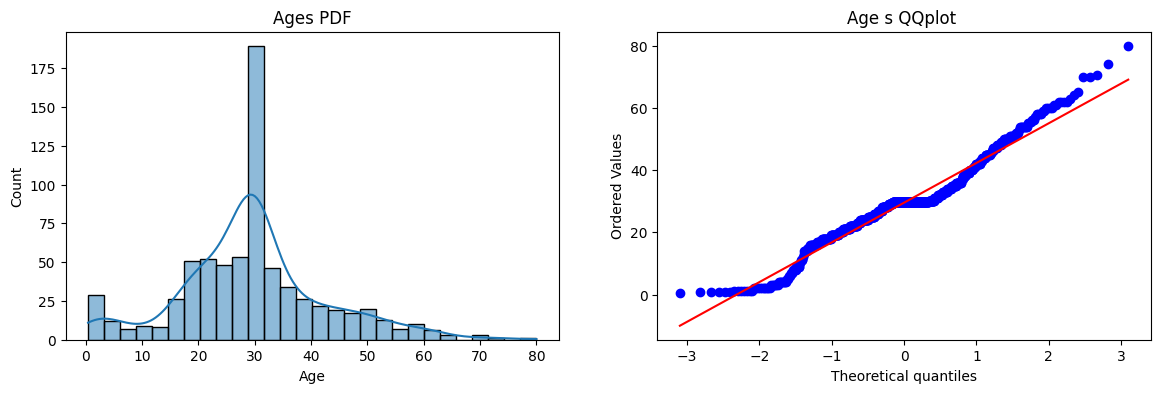

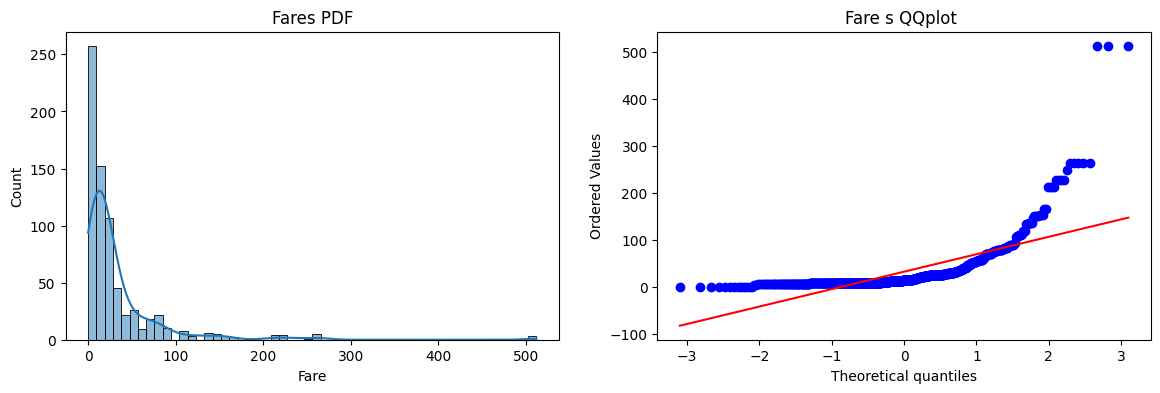

In [12]:
# A for loop to iterate over the X_train coloumns to look for Proability Density Function and the tailedness of the numeric values

for x in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[x],kde = True)
    plt.title(f'{x}s PDF')

    plt.subplot(122)
    stats.probplot(X_train[x],dist="norm",plot = plt)
    plt.title(f'{x} s QQplot ')
    plt.plot()


In [ ]:
# Check for the imbalancedness in the dataset
y_train.value_counts()*

Survived
0    444
1    268
Name: count, dtype: int64

In [14]:
# Applying log tranformation on X_train and X_test to check for improvements in the distibution and qq-plot 
# , basically we are aiming for normal distribution and decrease skewness.
log_transformer = FunctionTransformer( func = np.log1p )

In [15]:
# Applying this on X_train and X_test.
X_train_log_transformed = log_transformer.fit_transform(X_train)
X_test_log_transformed = log_transformer.transform(X_test)

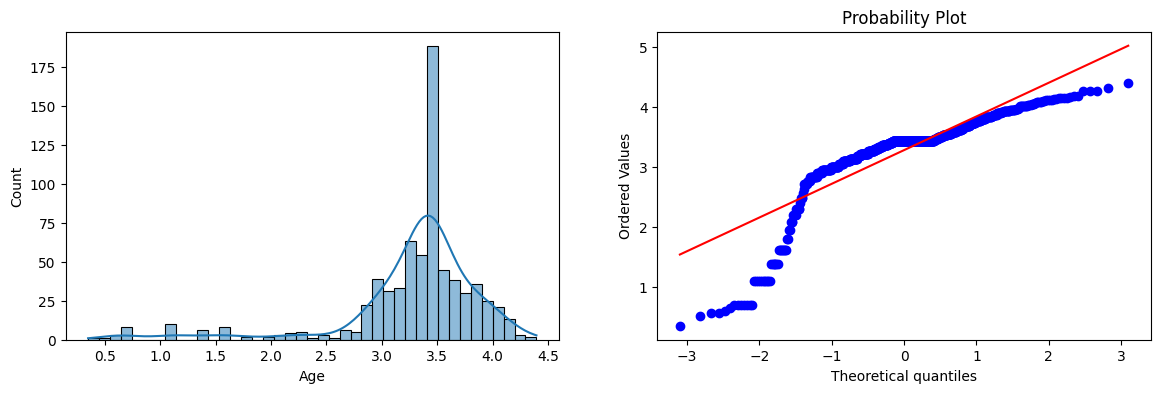

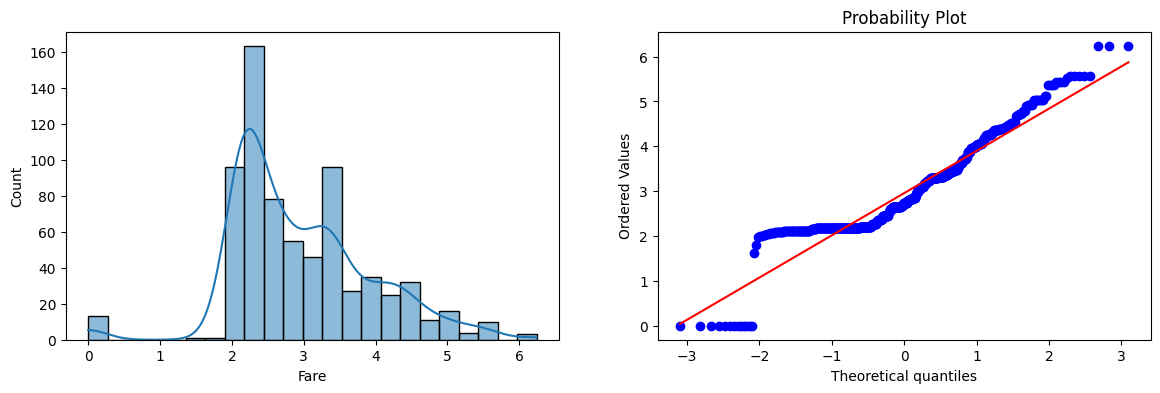

In [16]:
# Histplot and QQplot after transformation :
for x in X_train_log_transformed.columns:
    plt.figure(figsize = (14,4))
    plt.subplot(121)
    sns.histplot(X_train_log_transformed[x],kde=True)

    plt.subplot(122)
    stats.probplot(X_train_log_transformed[x],plot = plt , dist = 'norm')
    plt.plot()

In [17]:
# As we can see the LogTransformer is highly effective for 'Fare' and can be used for it
# on the other end the "Age" column's normal distribution got a bit skewed ,so we wont be using on it .0

# So we will use Column Transformer on the 'Fare' column only
# Also make sure to convert the array back to DataFrame as after the Transformer operation a numpy array is returned 

In [18]:
# Now lets try Yeo-johnson transformer "Exponent " one and check whether it improves the results
yeo_johnson_transformer = PowerTransformer( method ='yeo-johnson' )

In [19]:
X_train_yj = yeo_johnson_transformer.fit_transform(X_train)
X_test_yj = yeo_johnson_transformer.transform(X_test)

In [20]:
X_train_yj = pd.DataFrame(X_train_yj,columns = X_train.columns)

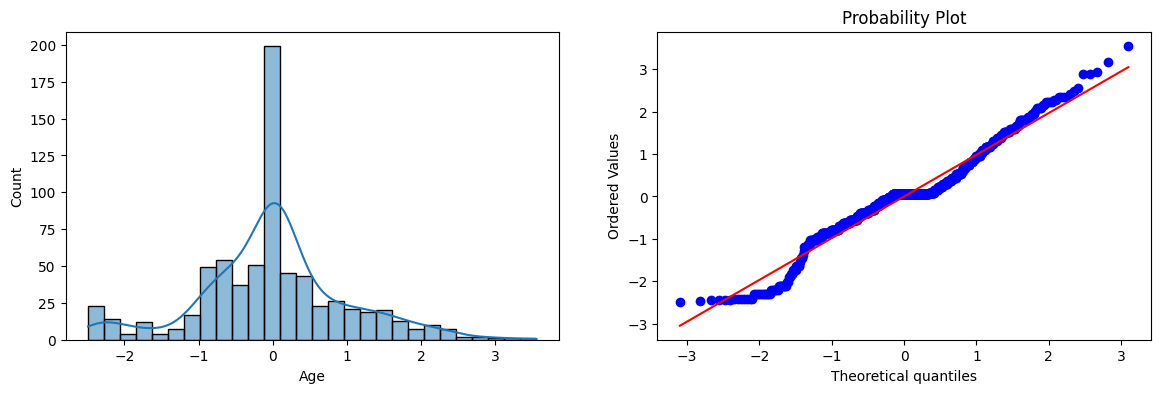

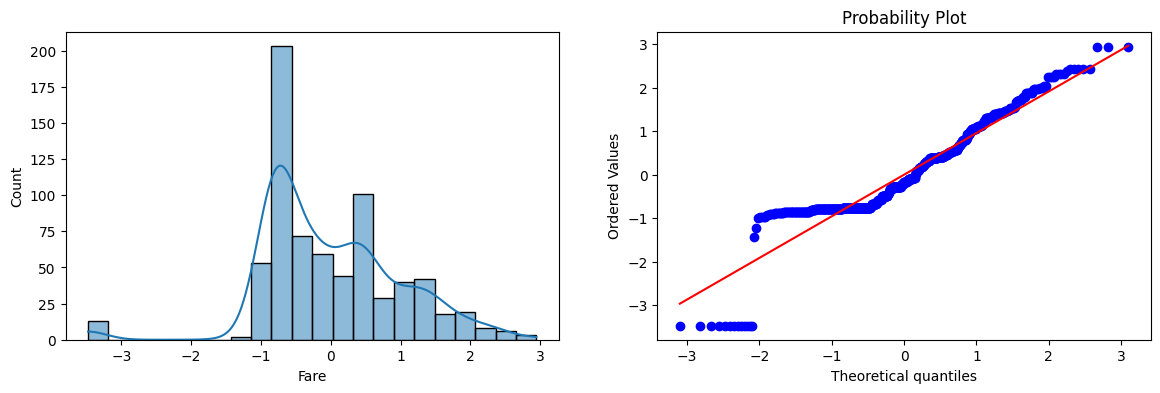

In [21]:
# Histplot and QQplot after yeo-johnson transformation :
for x in X_train_yj.columns:
    plt.figure(figsize = (14,4))
    plt.subplot(121)
    sns.histplot(X_train_yj[x],kde=True)

    plt.subplot(122)
    stats.probplot(X_train_yj[x],plot = plt , dist = 'norm')
    plt.plot()

In [22]:
yeo_johnson_transformer.lambdas_

array([ 0.84991107, -0.09664148])

In [23]:
# As we see this performs better and gives better result then log transformer .env

In [24]:
# Now lets try Square root transformer and check how it works 
square_root_transformer = FunctionTransformer(func = np.sqrt)

In [25]:
X_train_sqrt_transformed  = square_root_transformer.fit_transform(X_train)
X_test_sqrt_transformed = square_root_transformer.transform(X_test)

In [26]:
X_train_sqrt_transformed = pd.DataFrame(X_train_sqrt_transformed,columns = X_train.columns)

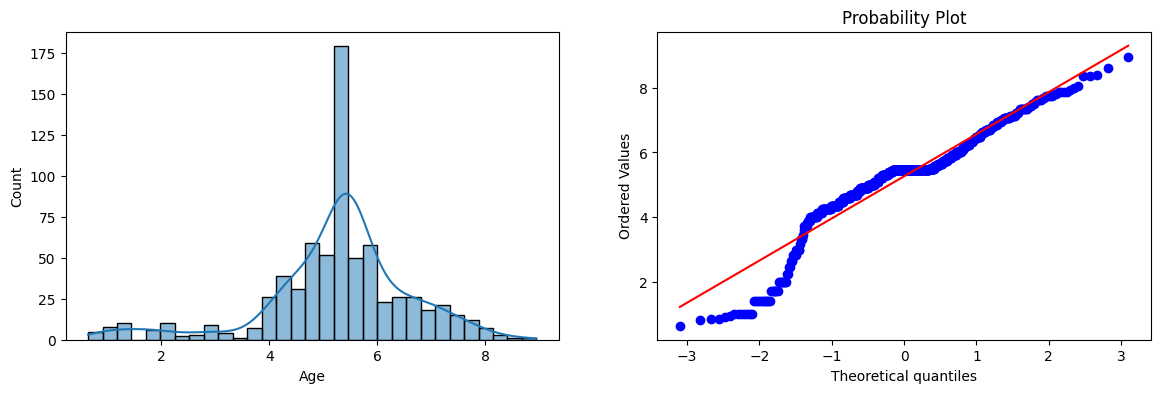

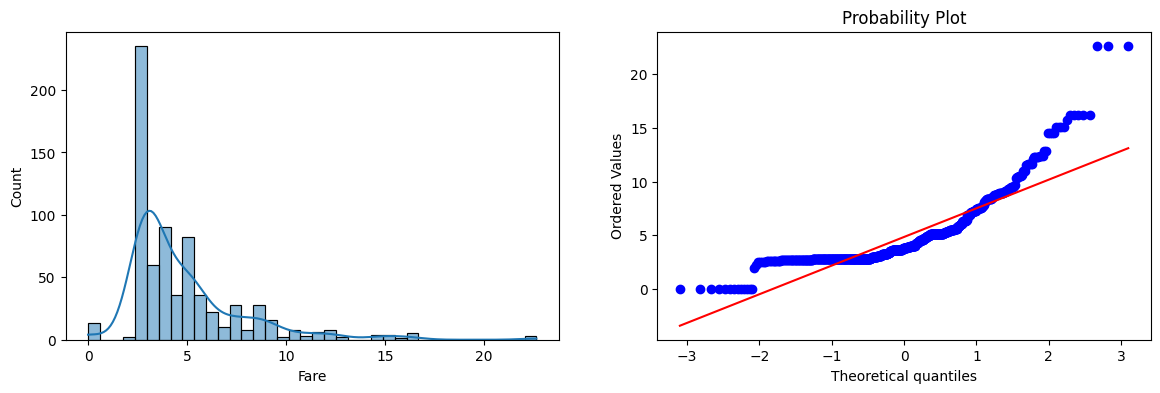

In [27]:
# Histplot and QQplot after Function : Sqrt transformation :
for x in X_train_sqrt_transformed.columns:
    plt.figure(figsize = (14,4))
    plt.subplot(121)
    sns.histplot(X_train_sqrt_transformed[x],kde=True)

    plt.subplot(122)
    stats.probplot(X_train_sqrt_transformed[x],plot = plt , dist = 'norm')
    plt.plot()

In [28]:
# Now lets try Reciprocal transformer and check how it works 
reciprocal_transformer = FunctionTransformer(lambda x : 1/(x+0.00001))

In [29]:
X_train_reciprocal_transformed  = reciprocal_transformer.fit_transform(X_train)
X_test_reciprocal_transformed = reciprocal_transformer.transform(X_test)

In [30]:
X_train_sqrt_transformed = pd.DataFrame(X_train_sqrt_transformed,columns = X_train.columns)

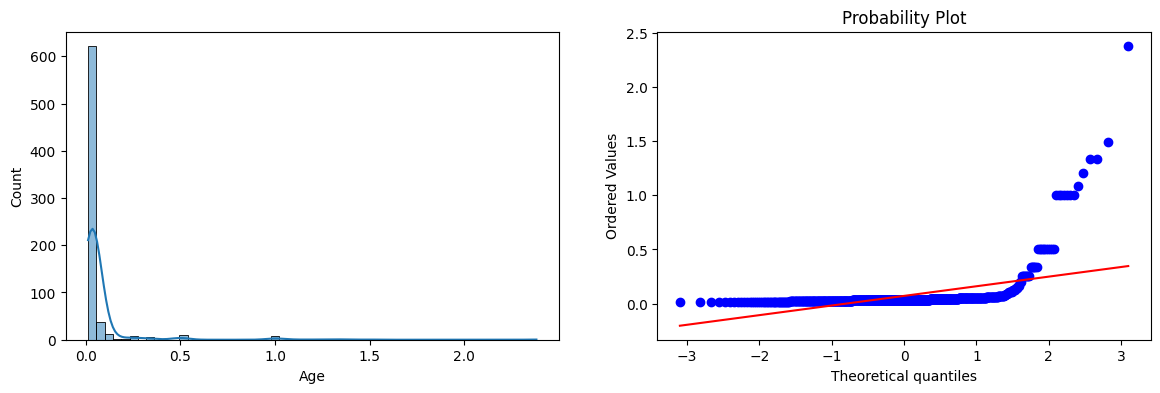

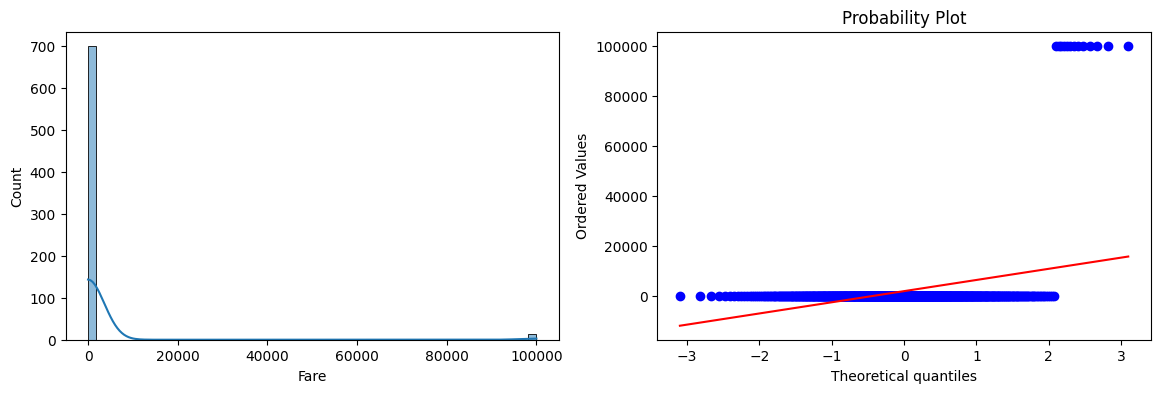

In [31]:
# Histplot and QQplot after Function : Sqrt transformation :
for x in X_train_reciprocal_transformed.columns:
    plt.figure(figsize = (14,4))
    plt.subplot(121)
    sns.histplot(X_train_reciprocal_transformed[x],kde=True)

    plt.subplot(122)
    stats.probplot(X_train_reciprocal_transformed[x],plot = plt , dist = 'norm')
    plt.plot()

In [32]:
# Now lets try 'Box-cox' transformercheck whether it improves the results (This can be checked before yeo-johnson).
box_cox_transformer = PowerTransformer( method ='box-cox' )

In [33]:
# If u try to apply with X_train ju will get a warning for negative value, So apply with +0.00001
X_train_bx = box_cox_transformer.fit_transform(X_train + 0.00001)
X_test_bx = box_cox_transformer.transform(X_test+ 0.00001)

In [34]:
X_train_bx = pd.DataFrame(X_train_bx,columns = X_train.columns)

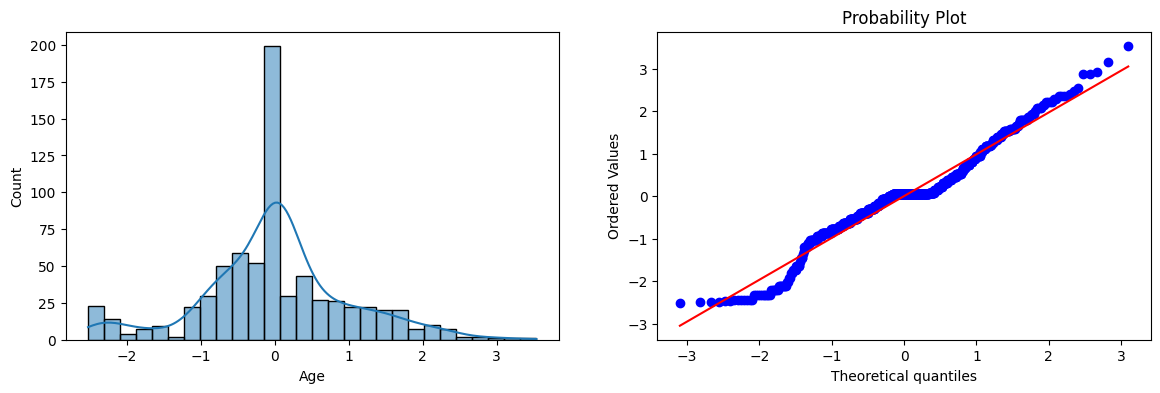

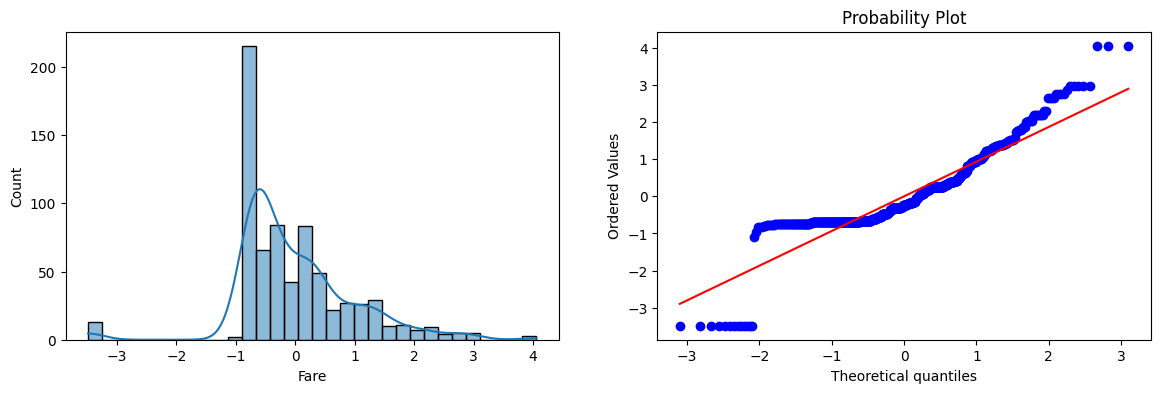

In [35]:
# Histplot and QQplot after Box-Cox transformation :
for x in X_train_bx.columns:
    plt.figure(figsize = (14,4))
    plt.subplot(121)
    sns.histplot(X_train_bx[x],kde=True)

    plt.subplot(122)
    stats.probplot(X_train_bx[x],plot = plt , dist = 'norm')
    plt.plot()

In [36]:
# This also gives a pretty good result like Yeo-Johnson but slightly less better 

In [37]:
# Conculsion at this point based on my observation we can do two things :
#   1) Apply yeo-johnson transformation on both X columns 
#    ( as it automaticaly detcts for normal distribution and doesnt interfere much wiht it ) , this is the best choice here . 
#   2) Otherwise we can apply yeo-johnson to 'Age' column so we dont interfere with it , and apply log tramsform to the 'Fare" column.

Now we will do all the steps using pipelining an transformers 

In [38]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

Column_preprocessor = ColumnTransformer(
    transformers = [
                        ('imputed_age_mean',SimpleImputer(strategy='mean'),['Age']),
                        ('yeo_johnson_on_age_and_fare',PowerTransformer(method='yeo-johnson'),['Age','Fare'])
    ],
    remainder = 'passthrough'
)

In [39]:
main_pipe = Pipeline(
        [
            ('column_pre',Column_preprocessor),
            ('logr',LogisticRegression())
        ]
)

In [40]:
main_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('column_pre', ...), ('logr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputed_age_mean', ...), ('yeo_johnson_on_age_and_fare', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If th

In [41]:
main_pipe.score(X_train,y_train)

0.6713483146067416

In [42]:
cvs_mean  = cross_val_score(main_pipe,X_train,y_train,cv = 10,scoring='accuracy').mean()

In [43]:
cvs_mean

np.float64(0.6628912363067292)

In [44]:
# We can add more columns especialy the 'Sex' column and the family and siblings column to improve the model using OneHotEncoder